In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys
sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

In [2]:
#data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/Ximea_Calibration/'
#data_folder = r'C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee\Data\Salix\Ximea_Calibration'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()


In [3]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
size_x, size_y = gain.shape
camera_parameters = {}
camera_parameters["gain"] = np.full((size_x, size_y), 1.2)
camera_parameters["offset"] = np.full((size_x, size_y), 100)
camera_parameters["variance"] = np.full((size_x, size_y), 0.9)
camera_parameters["readnoise"] = np.full((size_x, size_y), 0.2)
camera_parameters["rqe"] = np.full((size_x, size_y), 1)
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]

camera_parameters["masks"] = M_F.get_masks(size_x = size_x, size_y = size_y)

In [4]:
dye_data_folders = np.array([r'/media/jbeckwith/Ezra Seagat/JSB/20250325 Ximea camera install/DNA_PAINT_HiRes_20G/Atto542_10mW_561_lp561_bp_582_64_1/',
                             r'/media/jbeckwith/Ezra Seagat/JSB/20250325 Ximea camera install/DNA_PAINT_HiRES_20R/Atto655_40mW_638_635lp_1/',
                             r'/media/jbeckwith/Ezra Seagat/JSB/20250325 Ximea camera install/DNA_PAINT_HiRES_20R/Atto655_40mW_638_635lp_2/'])

In [5]:
peaks = np.array([0.56, 0.68, 0.68])

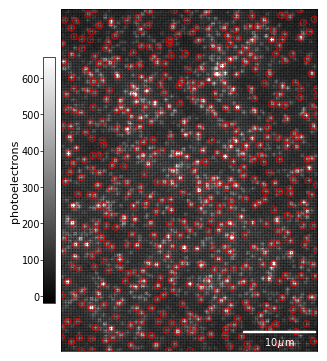

/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Code/Python/pyBayerSMLM/superres_notebooks/../src/ImageAnalysisFunctions.py:779: RuntimeWarning: invalid value encountered in sqrt
  std = np.sqrt(


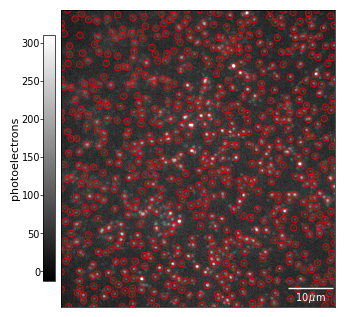

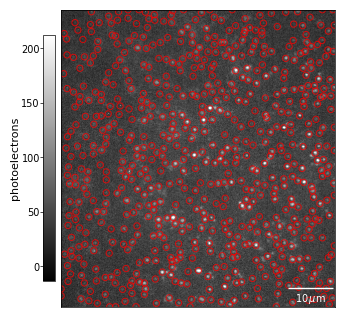

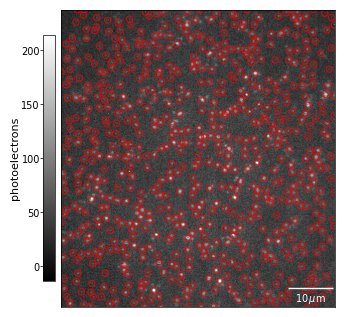

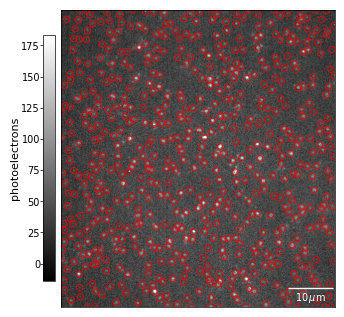

In [6]:
for pwl, dye_data_folder in enumerate(dye_data_folders):
    folder = os.path.join(dye_data_folder+'_analysis', 'SingleFrame_Fits')
    if not os.path.isdir(folder):
        os.makedirs(folder)

    peak_wl = peaks[pwl]
    
    files = np.sort([os.path.join(dye_data_folder, x) for x in os.listdir(dye_data_folder) if '.tif' in x])
    metadatafiles = np.sort([os.path.join(dye_data_folder, x) for x in os.listdir(dye_data_folder) if 'metadata' in x])
    start_x, start_y, width, height = IO.metadata_reader_imageJ(metadatafiles[0])
    masks = M_F.get_ROI_mask(ROI_x_start=start_x, ROI_y_start=start_y, width=width, height=height)
    
    import types
    smoothing_function = types.SimpleNamespace()
    smoothing_function.args = {"sigma" :  1.5}
    smoothing_function.extent =  1.5
    smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
    smoothing_function.data_arg = "image"
    frametosave = 0
    for FOV, file in enumerate(files):
        frame = 0
        while frame >= 0:
            
            try:
                first_FOV, weights_FOV = IO.read_tiff_tophotoelectrons(file_path=file, frame=frame, 
                                                                       smoothing_function=smoothing_function,
                                                                      gain_map=gain[start_x:start_x+width, start_y:start_y+height],
                                                                       offset_map=offset[start_x:start_x+width, start_y:start_y+height],
                                                                       rqe=rqe[start_x:start_x+width, start_y:start_y+height],
                                                                       read_noise=readnoise[start_x:start_x+width, start_y:start_y+height])
                frame += 1
            except:
                frame = -1
                continue
            points = SD_F.detect_puncta_in_image(first_FOV, pfa=1e-2, wavelength=peak_wl, NA=1.49)
            if frame == 1:
                fig, axs = plotter.one_column_plot()
                
                axs = plotter.image_scatter_plot(axs=axs, data=first_FOV, xdata=points[:, 0], ydata=points[:, 1], scatteralpha=0.75, 
                                                vmax=np.percentile(first_FOV.ravel(), 99.7),
                                                cbarlabel='photoelectrons')
                plt.savefig(os.path.join(folder, 'first_frame_spot_detection_sum.svg'), dpi=600, format='svg')
                plt.show()
                plt.close("all")

            if len(points) > 10:
                import types
                fitter = types.SimpleNamespace()
                fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "background_B", "background_G", "B", "G"])
                fitter.fit_function = I_AF.WLS_fit_colour
                fitter.pixel_order_indices = camera_parameters["pixel_order_indices"]
                
                results_matrix = {}
                params =  np.array(["xc", "yc", "A", "sigma", "b", "background_B", "background_G", "B", "G", "R",
                                    "xc_error", "yc_error", "A_error", "sigma_error", "b_error", "background_B_error",
                                    "background_G_error", "B_error", "G_error",
                                    "Reduced_Chisquared"])
                for param in params:
                    results_matrix[param] = np.zeros([len(points)])
                
                for i in np.arange(len(points)):
                    xcentre = points[i, 0]
                    ycentre = points[i, 1]
                    roi_size = 12
                    xmin = np.max([0, int(xcentre-roi_size/2)])
                    xmax = np.min([int(xcentre+roi_size/2), first_FOV.shape[0]])
                    ymin = np.max([0, int(ycentre-roi_size/2)])
                    ymax = np.min([int(ycentre+roi_size/2), first_FOV.shape[1]])
                    
                    if xmax-xmin != ymax-ymin:
                        for param in params:
                            results_matrix[param][i] = np.nan
                        continue
                    ROI_tofit = first_FOV[xmin:xmax, ymin:ymax]
                    weights_tofit = weights_FOV[xmin:xmax, ymin:ymax]
                    masks_tofit = deepcopy(masks)
                    for key in masks:
                        masks_tofit[key] = masks_tofit[key][xmin:xmax, ymin:ymax]
                        
                    x_in = 6
                    y_in = 6
                    A = 500
                    sigma = 1.
                    background = 4.
                    background_Bmin = 0.1
                    background_Gmin = 0.6
                    Bmin = 0.1
                    Gmin = 0.6
                    initial_guess = np.array([x_in, y_in, A, sigma, background, background_Bmin, background_Gmin, Bmin, Gmin])
                    masks_3d = np.dstack(
                                [masks_tofit[x] for x in masks_tofit.keys()]
                            )
                    args = {
                        "data": ROI_tofit,
                        "initial_guess": initial_guess,
                        "masks": masks_3d,
                        "weights": weights_tofit,
                        "pixel_order": camera_parameters["pixel_order_indices"],
                        "display": True,
                        "background_Bmin": 0,
                        "background_Gmin": 0,
                        "background_Bmax": 1,
                        "background_Gmax": 1,
                        "Bmin": 0,
                        "Gmin": 0,
                        "Bmax": 1,
                        "Gmax": 1,
                        "minsigma": 0.9,
                        "maxsigma": 2.5,
                    }
                    result, var, fit = fitter.fit_function(**args)
                    R = 1 - np.sum(result.x[-2:])
                    reduced_chi = I_AF.reduced_chisqared(ROI_tofit, fit, weights_tofit, initial_guess)
                    result.x = np.hstack([result.x, R, var, reduced_chi])
                    for j, param in enumerate(params):
                        results_matrix[param][i] = result.x[j]
                
                pl.DataFrame(data=results_matrix).write_csv(os.path.join(folder, 'Image_PunctaAnalysis_FOV_'+str(FOV).zfill(6)+'_Frame'+str(frame).zfill(6)+'.csv'))
            else:
                continue